In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from scipy.linalg import null_space
from scipy.linalg import solve as linsolve
from scipy.linalg import svd
from scipy.linalg import eig as eigenvalues
from utils import *
rc('text', usetex=True)
rc('font', family='sans-serif', serif=['Helvetica'], size=18)

## Example: 3-level internal states #

In [2]:
def HR(Delta, Omega):
    """3-level Rubidium Hamiltonian"""
    Omega1 = Omega
    Omega2 = Omega
    Delta1 = Delta / 10
    Delta2 = Delta
    H = np.array([
        [0, 0, Omega1 / 2],
        [0, Delta1, Omega2 / 2],
        [Omega1 / 2, Omega2 / 2, Delta2]
    ], dtype=complex)
    return H


def LDiss1(r):
    """Dissipator 1 for Rubidium"""
    def func(gamma_d):
        L = gamma_d * np.array([[0, 1, 0], [0, 0, 0], [0, 0, 0]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def LDiss2(r):
    """Dissipator 2 for Rubidium"""
    def func(gamma_d):
        L = gamma_d * np.array([[0, 0, 1], [0, 0, 0], [0, 0, 0]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def LD1(r):
    """Dephasing dissipator 1 for Rubidium"""
    def func(gamma_phi):
        L = gamma_phi * np.array([[0, 0, 0], [0, 1, 0], [0, 0, -1]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def LD2(r):
    """Dephasing dissipator 2 for Rubidium"""
    def func(gamma_phi):
        L = gamma_phi * np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=complex)
        return lindblad_dissipator(L, r)
    return func


def diss(r):
    """Total dissipator for Rubidium system"""
    def func(Delta, Omega):
        gamma_d = 2 * np.pi * 6.1
        gamma_phi = 0.0
        return (LDiss1(r)(gamma_d) + 
                LDiss2(r)(gamma_d) + 
                LD1(r)(gamma_phi) + 
                LD2(r)(gamma_phi))
    return func

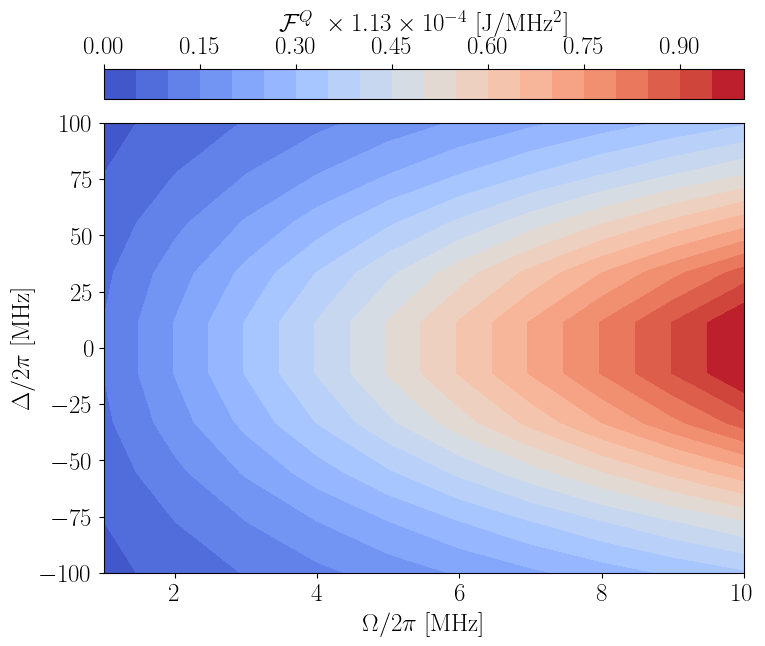

Computing Liouvillian Gap for 3x3 system...
Liouvillian gap between 7.35e+02 and 7.36e+02.


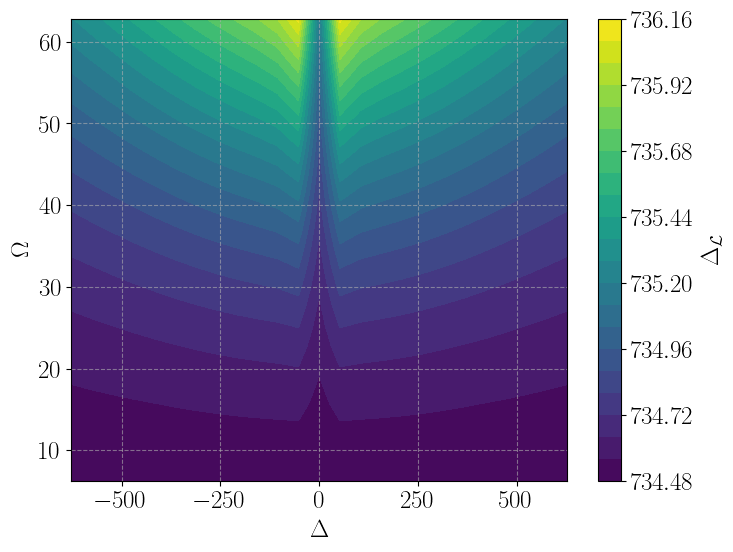

Starting cycle integration for d=3 system...
--- Results ---
Geometric Heat: -3.1667239676339647
Dissipated Heat: 5.671833067101214e-08
Net: -3.166723910915634
Temperature change over the cycle: -2.4188173350629594e-11 K


In [11]:
H1 = HR
range_Delta = [r'$\Delta$', -2 * np.pi * 100, 2 * np.pi * 100] # 2π × [-100, 100] MHz
range_Omega = [r'$\Omega$', 2 * np.pi, 2 * np.pi * 10] # 2π × [1, 10] MHz

p1_grid, p2_grid, curvature_data, max_val = old_heat_curvature(
    H1, H1, diss,
    ranges=[range_Delta, range_Omega],
    points=10
)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
cp = ax.contourf(p2_grid / (2 * np.pi), p1_grid / (2 * np.pi), np.transpose(curvature_data), levels=20, cmap='coolwarm')
cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
mantissa, exp = f"{max_val:.2e}".split('e')
cbar = fig.colorbar(cp, cax=cax, orientation='horizontal', label=rf'$\mathcal{{F}}^{{Q}} \; \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/MHz^2]}}$')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
ax.set_xlabel(r'$\Omega / 2 \pi \; \mathrm{[MHz]}$')
ax.set_ylabel(r'$\Delta / 2 \pi \; \mathrm{[MHz]}$')
plt.savefig('figures/3lvl_Rb.pdf', bbox_inches='tight')
plt.show()

# Liouvillian Gap Example
liouvillian_gap(
    H1,
    diss,
    params=[r'$\Delta$', r'$\Omega$'],
    ranges=[range_Delta,range_Omega],
    points=25
)

# Reversible and Dissipative Heat Example
# Cycle path goes over the whole parameter range
q_geo, q_diss = compute_cycle_heats(
    H1,
    H1,
    diss,
    p_min=[range_Delta[1], range_Omega[1]],
    p_max=[range_Delta[2], range_Omega[2]],
    tau= 2* np.pi* 100,
    points=100,
    clockwise=True
)

kB = 1.380649e-23  # Boltzmann constant in J/K
hbar = 1.0545718e-34  # Reduced Planck constant in J*s
print("Temperature change over the cycle:", (q_geo + q_diss) * hbar / kB, "K")

## TLS-Mot model ##

In [14]:
N_mot = 4

def H_motion_tls(delta_0, omega_rabi, omega_mot):
    """
    Motion-TLS Hamiltonian.
    delta_0: detuning (-50 to 50 KHz)
    omega_rabi: Rabi frequency (2 pi 10-1e4 Hz)
    omega_mot: Motional frequency (2 pi 50-500 Hz)
    """
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()
    
    # Physical constants (using higher precision)
    x0 = np.longdouble(1e-5) # 0-10 \mu m
    mu_B = np.longdouble(9.27e-24) #  J/T
    gF = np.longdouble(0.5)
    B0 = np.longdouble(1e-3) # T
    dB = np.longdouble(10.0) # 1000 G/cm = 10 T/m
    hbar = np.longdouble(1.05e-34) # J s
    m = np.longdouble(1.44e-25) # kg
    
    # Oscillator length scale
    x_ho = np.sqrt(hbar / (np.longdouble(2) * m * omega_mot))
    eta = gF * mu_B * x_ho * dB / hbar
    
    # Hamiltonian components
    H_mot = omega_mot * (np.kron(sigma0, adag @ a) - x0 / x_ho * np.kron(sigma0, adag + a))
    H_spin = np.longdouble(0.5) * np.kron(delta_0 * sigma3 + omega_rabi * sigma1, np.eye(N_mot))
    H_coup = np.kron(sigma3, -0.5 * eta * (adag + a))

    return H_mot + H_spin + H_coup

def H_motion_tls_ref(delta_0, omega_rabi, omega_mot):
    """Reference Hamiltonian for Motion-TLS (photon number operator)"""
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()

    hbar = np.longdouble(1.05e-34) # J s
    m = np.longdouble(1.44e-25) # kg
    x0 = np.longdouble(1e-5) # 0-10 \mu m
    x_ho = np.sqrt(hbar / (np.longdouble(2) * m * omega_mot))

    H_mot = omega_mot * (np.kron(sigma0, adag @ a) - x0 / x_ho * np.kron(sigma0, adag + a))
    return H_mot


def diss_motion_tls(r):
    """Dissipator for Motion-TLS system"""
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()
    
    def func(delta_0, omega_rabi, omega_mot):

        gamma_up = np.longdouble(1e5) # Hz
        #gamma_phi = np.longdouble(100.0) # Hz
        gamma_m = np.longdouble(50.0) # Hz
        #n_th = np.longdouble(1000) # thermal photon number

        L_up = np.sqrt(gamma_up) * np.kron(sigma_up, np.eye(N_mot))
        #L_phi = np.sqrt(gamma_phi / np.longdouble(2)) * np.kron(sigma3, np.eye(N_mot))
        #L_cool = np.sqrt(gamma_m * (n_th + np.longdouble(1))) * np.kron(np.eye(2), a)
        #L_heat = np.sqrt(gamma_m * n_th) * np.kron(np.eye(2), adag)
        L_mot = np.sqrt(gamma_m) * np.kron(np.eye(2), a + adag)
        
        return (lindblad_dissipator(L_up, r) +
                lindblad_dissipator(L_mot, r) )
        
    return func

## Example: Motion-TLS Coupled System with $\lambda=(\Omega,\Delta)$ ##

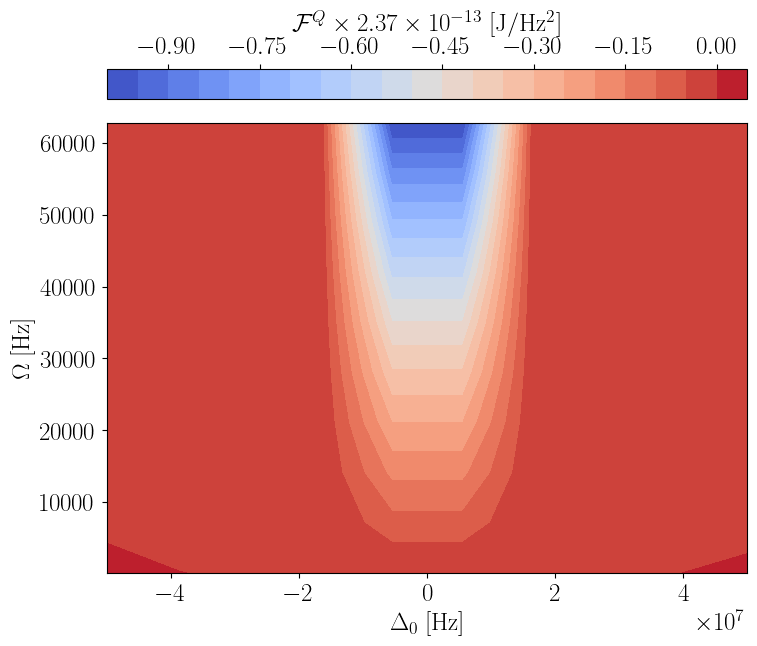

Computing Liouvillian Gap for 8x8 system...
Liouvillian gap between 8.80e-03 and 8.80e-03.


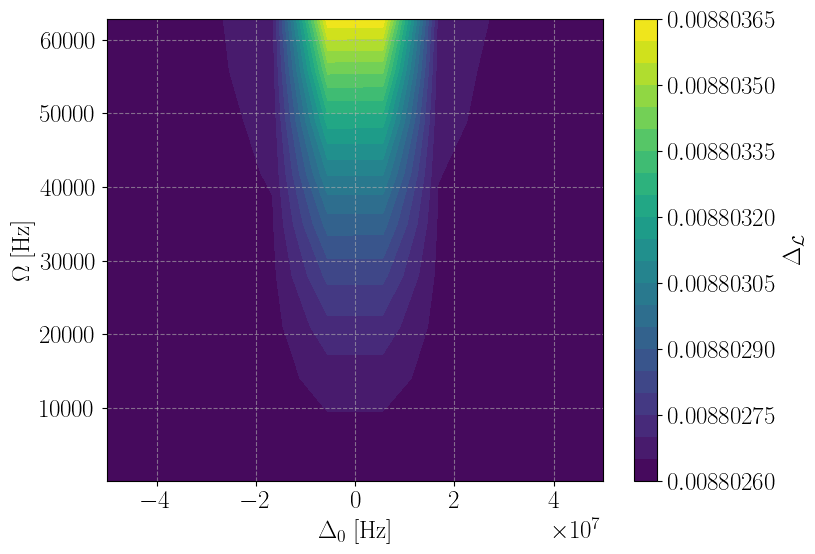

Starting cycle integration for d=8 system...
--- Results ---
Geometric Heat: -1007868.316892484
Dissipated Heat: 114085.86122575487
Net: -893782.4556667291
Temperature change over the cycle: -6.8269181600890791236e-06 K


In [17]:
Delta0_range = [r'$\Delta_0$', -50 * 1e6, 50 * 1e6] # Hz
Omega_range = [r'$\Omega$', 2 * np.pi * 20, 2 * np.pi * 1e4] # Hz

def H_ex1(delta_0, omega_rabi):
    return H_motion_tls(delta_0, omega_rabi, 2 * np.pi * 500)
def H_ref_ex1(delta_0, omega_rabi):
    return H_motion_tls_ref(delta_0, omega_rabi, 2 * np.pi * 500)
def diss_ex1(r):
    def func(delta_0, omega_rabi):  # Then returns a function for parameters
        return diss_motion_tls(r)(delta_0, omega_rabi, 2 * np.pi * 500)
    return func

p1_grid_mtls, p2_grid_mtls, curvature_mtls, max_val_mtls = old_heat_curvature(
    H_ex1, H_ref_ex1, diss_ex1,
    ranges=[Delta0_range, Omega_range],
    points=10
)

# Plot Heat Curvature
fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
cp = ax.contourf(p1_grid_mtls, p2_grid_mtls, curvature_mtls, levels=20, cmap='coolwarm')
cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
mantissa, exp = f"{max_val_mtls:.2e}".split('e')
cbar = fig.colorbar(cp, cax=cax, orientation='horizontal',
    label=rf'$\mathcal{{F}}^Q \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/Hz^2]}}$')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
ax.set_xlabel(r'$\Delta_0 \; \mathrm{[Hz]}$')
ax.set_ylabel(r'$\Omega \; \mathrm{[Hz]}$')
plt.savefig('figures/motion_tls_Delta_Omega.pdf', bbox_inches='tight')
plt.show()

# Liouvillian Gap
liouvillian_gap(
    H_ex1,
    diss_ex1,
    params=[r'$\Delta_0 \; \mathrm{[Hz]}$', r'$\Omega \; \mathrm{[Hz]}$'],
    ranges=[Delta0_range, Omega_range],
    points=10
)

# Cycle heats
q_geo_mtls, q_diss_mtls = compute_cycle_heats(
    H_ex1,
    H_ref_ex1,
    diss_ex1,
    p_min=[Delta0_range[1], Omega_range[1]],
    p_max=[Delta0_range[2], Omega_range[2]],
    tau=2 * np.pi * 80,
    points=100,
    clockwise=True
)

kB = 1.380649e-23  # Boltzmann constant in J/K
hbar = 1.0545718e-34  # Reduced Planck constant in J*s
print("Temperature change over the cycle:", (q_geo_mtls + q_diss_mtls) * hbar / kB, "K")

In [18]:
# Compute tau from Liouvillian gap
# The natural timescale is the inverse of the Liouvillian gap: tau = 1/gap

# Example: use the gap at the center of the parameter range
Delta0_center = (Delta0_range[1] + Delta0_range[2]) / 2
Omega_center = (Omega_range[1] + Omega_range[2]) / 2

# Construct the Liouvillian at this point
H_center = H_ex1(Delta0_center, Omega_center)
d = H_center.shape[0]
d2 = d * d

L_mat = np.zeros((d2, d2), dtype=complex)
for col in range(d2):
    e = np.zeros((d, d), dtype=complex)
    e[col // d, col % d] = 1.0
    L_e = -1j * (H_center @ e - e @ H_center) + diss_ex1(e)(Delta0_center, Omega_center)
    L_mat[:, col] = L_e.flatten()

# Compute eigenvalues
evals, _ = eigenvalues(L_mat)
sorted_reals = np.sort(np.real(evals))[::-1]
gap_value = np.abs(sorted_reals[1])

print(f"Liouvillian gap at center: {gap_value:.4e}")

# Natural timescale from gap (in atomic units where hbar=1)
tau_from_gap = 1.0 / gap_value
print(f"tau from gap (atomic units): {tau_from_gap:.4e}")

# Convert to seconds
hbar = 1.0545718e-34  # J*s
# Characteristic energy scale (e.g., from Omega_center)
E_char = hbar * Omega_center
tau_seconds = hbar / E_char
print(f"tau in seconds (approximate): {tau_seconds:.4e} s")


Liouvillian gap at center: 1.2351e-02
tau from gap (atomic units): 8.0962e+01
tau in seconds (approximate): 3.1767e-05 s


## Example: TLS-Mot with $\lambda=(\Omega, \omega)$ ##

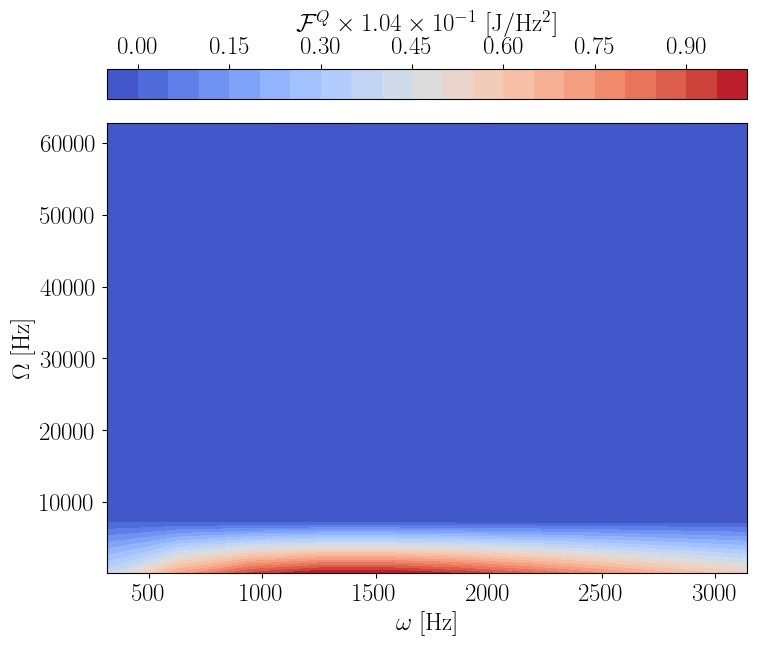

Computing Liouvillian Gap for 8x8 system...
Liouvillian gap between 2.80e-06 and 9.57e-03.


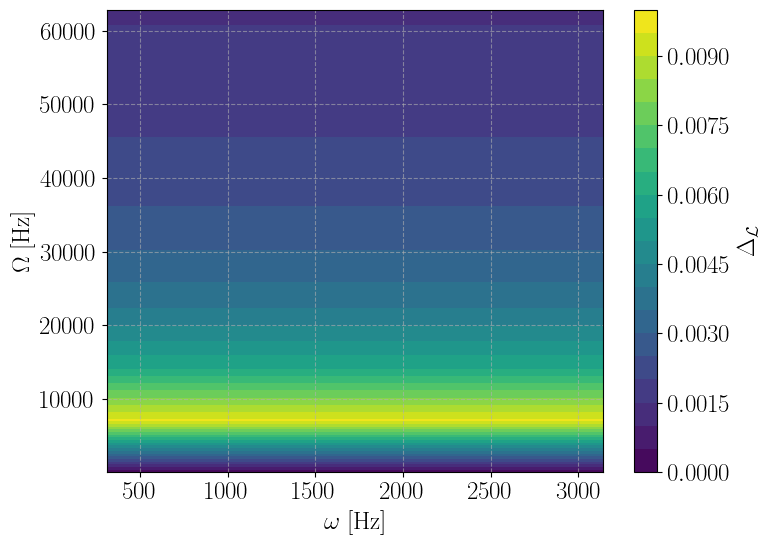

Starting cycle integration for d=8 system...
--- Results ---
Geometric Heat: -306666.40248106356
Dissipated Heat: -276663323.132657
Net: -276969989.535138
Temperature change over the cycle: -0.0021155611629751780227 K


In [26]:
omega_mot_range = [r'$\omega$', 2 * np.pi * 50, 2 * np.pi * 500] # Hz
Omega_range = [r'$\Omega$', 2 * np.pi * 20, 2 * np.pi * 1e4] # Hz

def H_ex2(omega_rabi, omega_mot):
    return H_motion_tls(50 * 1e3, omega_rabi, omega_mot)
def H_ref_ex2(omega_rabi, omega_mot):
    return H_motion_tls_ref(50 * 1e3, omega_rabi, omega_mot)
def diss_ex2(r):
    def func(omega_rabi, omega_mot):  # Then returns a function for parameters
        return diss_motion_tls(r)(50 * 1e3, omega_rabi, omega_mot)
    return func

p1_grid_mtls, p2_grid_mtls, curvature_mtls, max_val_mtls = old_heat_curvature(
    H_ex2, H_ref_ex2, diss_ex2,
    ranges=[omega_mot_range, Omega_range],
    points=10
)

# Plot Heat Curvature
fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
cp = ax.contourf(p1_grid_mtls, p2_grid_mtls, curvature_mtls, levels=20, cmap='coolwarm')
cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
mantissa, exp = f"{max_val_mtls:.2e}".split('e')
cbar = fig.colorbar(cp, cax=cax, orientation='horizontal',
    label=rf'$\mathcal{{F}}^Q \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/Hz^2]}}$')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
ax.set_xlabel(r'$\omega \; \mathrm{[Hz]}$')
ax.set_ylabel(r'$\Omega \; \mathrm{[Hz]}$')
plt.savefig('figures/motion_tls_Omega_omega.pdf', bbox_inches='tight')
plt.show()

# Liouvillian Gap
liouvillian_gap(
    H_ex2,
    diss_ex2,
    params=[r'$\omega \; \mathrm{[Hz]}$', r'$\Omega \; \mathrm{[Hz]}$'],
    ranges=[omega_mot_range,Omega_range],
    points=10
)

# Cycle heats
q_geo_mtls, q_diss_mtls = compute_cycle_heats(
    H_ex2,
    H_ref_ex2,
    diss_ex2,
    p_min=[omega_mot_range[1], Omega_range[1]],
    p_max=[omega_mot_range[2], Omega_range[2]],
    tau=2 * np.pi * 1000,
    points=100,
    clockwise=False
)

kB = 1.380649e-23  # Boltzmann constant in J/K
hbar = 1.0545718e-34  # Reduced Planck constant in J*s
print("Temperature change over the cycle:", (q_geo_mtls + q_diss_mtls) * hbar / kB, "K")

## Exmaple: TLS-Mot $\lambda=(\Delta,\omega)$ ##

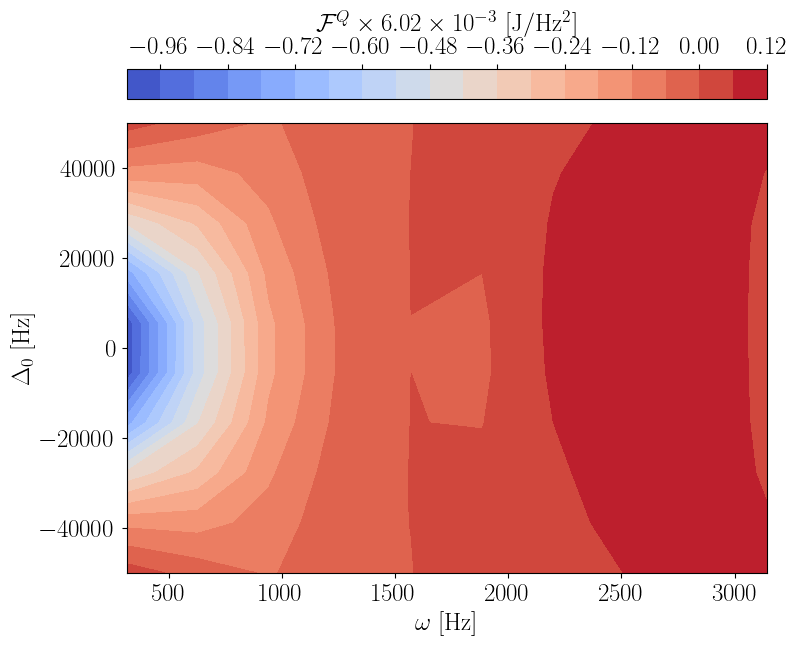

Computing Liouvillian Gap for 8x8 system...
Liouvillian gap between 2.13e-04 and 4.14e-02.


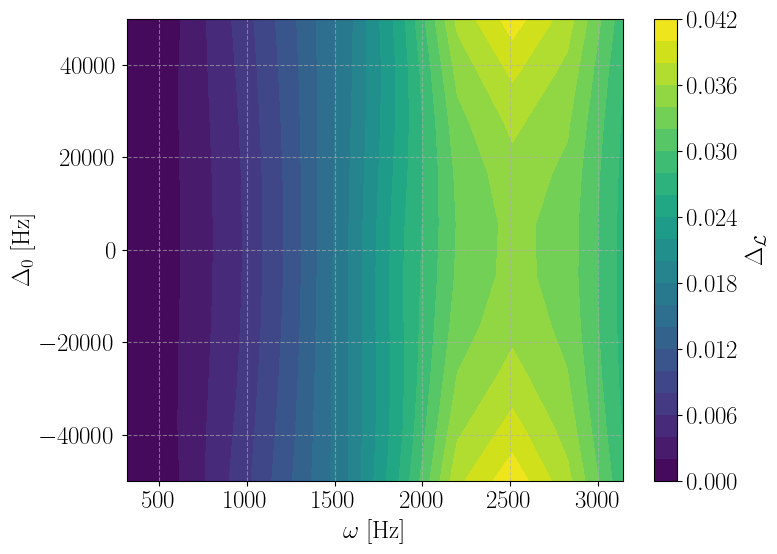

Starting cycle integration for d=8 system...
--- Results ---
Geometric Heat: -122795.04724752237
Dissipated Heat: 61122.62950847557
Net: -61672.417739046796
Temperature change over the cycle: -4.7106826271860921537e-07 K


In [27]:
omega_mot_range = [r'$\omega$', 2 * np.pi * 50, 2 * np.pi * 500] # Hz
delta_range = [r'$\Delta_0$', -50 * 1e3, 50 * 1e3] # Hz

def H_ex3(omega_mot, delta_0):
    return H_motion_tls(delta_0, 2 * np.pi * 1e4, omega_mot)
def H_ref_ex3(omega_mot, delta_0):
    return H_motion_tls_ref(delta_0, 2 * np.pi * 1e4, omega_mot)
def diss_ex3(r):
    def func(omega_mot, delta_0):  # Then returns a function for parameters
        return diss_motion_tls(r)(delta_0, 2 * np.pi * 1e4, omega_mot)
    return func

p1_grid_mtls, p2_grid_mtls, curvature_mtls, max_val_mtls = old_heat_curvature(
    H_ex3, H_ref_ex3, diss_ex3,
    ranges=[omega_mot_range, delta_range],
    points=10
)

# Plot Heat Curvature
fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
cp = ax.contourf(p1_grid_mtls, p2_grid_mtls, curvature_mtls, levels=20, cmap='coolwarm')
cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
mantissa, exp = f"{max_val_mtls:.2e}".split('e')
cbar = fig.colorbar(cp, cax=cax, orientation='horizontal',
    label=rf'$\mathcal{{F}}^Q \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/Hz^2]}}$')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
ax.set_xlabel(r'$\omega \; \mathrm{[Hz]}$')
ax.set_ylabel(r'$\Delta_0 \; \mathrm{[Hz]}$')
plt.savefig('figures/motion_tls_Delta_omega.pdf', bbox_inches='tight')
plt.show()

# Liouvillian Gap
liouvillian_gap(
    H_ex3,
    diss_ex3,
    params=[r'$\omega \; \mathrm{[Hz]}$', r'$\Delta_0 \; \mathrm{[Hz]}$'],
    ranges=[omega_mot_range,delta_range],
    points=10
)

# Cycle heats
q_geo_mtls, q_diss_mtls = compute_cycle_heats(
    H_ex3,
    H_ref_ex3,
    diss_ex3,
    p_min=[omega_mot_range[1], delta_range[1]],
    p_max=[omega_mot_range[2], delta_range[2]],
    tau=2 * np.pi * 1000,
    points=100,
    clockwise=True
)

kB = 1.380649e-23  # Boltzmann constant in J/K
hbar = 1.0545718e-34  # Reduced Planck constant in J*s
print("Temperature change over the cycle:", (q_geo_mtls + q_diss_mtls) * hbar / kB, "K")